# ClinVar pathogenic-variant enrichment in Pfam-coding exons

**Hypothesis:** missense pathogenic variants are enriched in CDS exons that code
for Pfam-A domains, relative to benign controls. This is the canonical "domains
are constrained" finding, reframed at the **exon** level rather than the residue
level.

The workflow:
1. Download the latest ClinVar VCF (GRCh38), filter to missense SNVs with
   `CLNSIG ∈ {Pathogenic, Likely_pathogenic, Benign, Likely_benign}`.
2. Pick the top N genes by pathogenic count (default 100), giving ~10K variants.
3. For each variant, ask: does it fall in a CDS exon that codes at least one
   Pfam-A domain? (`prot2exon` already mapped the Pfam atlas in notebook 1.)
4. Fisher's exact test: pathogenic enrichment in domain-coding exons.

### Inputs (from notebook 1 + ClinVar FTP)

| File | Source |
|---|---|
| `pfam_atlas/domain_cds_segments.tsv` | output of notebook 1 |
| `clinvar.vcf.gz` | https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz |

In [1]:
import gzip, os, subprocess, urllib.request
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact

DATA = Path.home() / "Desktop" / "protein2genomic_data"
CLINVAR_URL = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz"
CLINVAR_VCF = DATA / "clinvar.vcf.gz"
# The domain-coding interval set: the union of every Pfam-A-coding exon across
# all isoforms (a variant counts if it falls in any isoform's domain exon).
# Built by the atlas notebooks; falls back to the older atlas if present.
PFAM_OUT    = DATA / "atlas_v115" if (DATA / "atlas_v115").exists() else DATA / "pfam_atlas"

if not CLINVAR_VCF.exists():
    print(f"downloading {CLINVAR_URL} ...")
    urllib.request.urlretrieve(CLINVAR_URL, CLINVAR_VCF)
print(f"VCF: {CLINVAR_VCF.stat().st_size / 1e6:.0f} MB")

VCF: 192 MB


## 1. Parse ClinVar to a tidy DataFrame

Streaming parse (the VCF is ~600 MB but most lines aren't relevant). Keep only
missense SNVs in autosomes + X + Y with the four CLNSIG values we care about.

In [2]:
WANTED_CLNSIG = {"Pathogenic", "Likely_pathogenic", "Benign", "Likely_benign"}
rows = []
with gzip.open(CLINVAR_VCF, "rt") as f:
    for line in f:
        if line.startswith("#"):
            continue
        chrom, pos, _, ref, alt, _, _, info = line.rstrip("\n").split("\t")[:8]
        if len(ref) != 1 or len(alt) != 1:    # SNV only
            continue
        attrs = dict(part.split("=", 1) for part in info.split(";") if "=" in part)
        if attrs.get("MC", "").find("SO:0001583") == -1:  # missense
            continue
        sig = attrs.get("CLNSIG", "")
        if sig not in WANTED_CLNSIG:
            continue
        gene_info = attrs.get("GENEINFO", "")
        gene = gene_info.split(":", 1)[0] if gene_info else ""
        rows.append((chrom, int(pos), ref, alt, sig, gene))

clinvar = pd.DataFrame(rows, columns=["chrom","pos","ref","alt","clnsig","gene"])
clinvar["category"] = np.where(clinvar["clnsig"].str.contains("athog"),
                                "pathogenic", "benign")
print(clinvar["category"].value_counts())
print(f"\n{clinvar['gene'].nunique():,} unique genes")

category
benign        137359
pathogenic     58039
Name: count, dtype: int64

15,193 unique genes


## 2. Pick top-N genes by pathogenic burden

In [3]:
TOP_N = 100
top_genes = (clinvar.query("category=='pathogenic'")
             .groupby("gene").size().nlargest(TOP_N).index)
sub = clinvar[clinvar["gene"].isin(top_genes)].copy()
print(f"{TOP_N} top genes → {len(sub):,} variants "
      f"({(sub['category']=='pathogenic').sum():,} pathogenic, "
      f"{(sub['category']=='benign').sum():,} benign)")

100 top genes → 25,453 variants (20,832 pathogenic, 4,621 benign)


## 3. Build Pfam-coding genomic interval index

From notebook 1's `domain_cds_segments.tsv`, collect the genomic intervals that
overlap any Pfam-A domain. A variant counts as "in a domain-coding exon" if its
position falls inside any of these intervals.

In [4]:
seg = pd.read_csv(PFAM_OUT / "domain_cds_segments.tsv", sep="\t", low_memory=False,
                  usecols=["chrom","feature_genomic_start","feature_genomic_end","overlaps_domain"])
seg = seg.query("overlaps_domain == 'coding_overlap'").copy()
seg["chrom"] = seg["chrom"].astype(str).str.removeprefix("chr")
# Group into per-chrom sorted start/end arrays for fast lookup via bisect.
from collections import defaultdict
import bisect
raw = defaultdict(list)
for c, s, e in seg[["chrom","feature_genomic_start","feature_genomic_end"]].itertuples(index=False):
    raw[c].append((int(s), int(e)))
intervals_by_chrom = {}   # chrom -> (starts_sorted, ends_sorted)
total_intervals = 0
for c, pairs in raw.items():
    pairs.sort()
    starts = [s for s,_ in pairs]
    ends   = [e for _,e in pairs]
    intervals_by_chrom[c] = (starts, ends)
    total_intervals += len(pairs)
print(f"indexed {total_intervals:,} domain-coding intervals across {len(intervals_by_chrom)} chromosomes")

indexed 1,462,109 domain-coding intervals across 25 chromosomes


In [5]:
def in_domain(chrom: str, pos: int) -> bool:
    chrom = chrom.removeprefix("chr")
    arrs = intervals_by_chrom.get(chrom)
    if arrs is None:
        return False
    starts, ends = arrs
    # Rightmost interval whose start <= pos. Walk left while overlap is possible.
    i = bisect.bisect_right(starts, pos) - 1
    while i >= 0:
        if ends[i] >= pos:
            return True
        # ends not sorted; need to keep walking left until starts[i] is too small
        # to ever reach pos. CDS exons are bounded (rarely >10kb), so 100kb cutoff is safe.
        if starts[i] + 100_000 < pos:
            break
        i -= 1
    return False

sub["in_pfam_exon"] = [in_domain(c, p) for c, p in zip(sub["chrom"], sub["pos"])]
print(sub.groupby(["category","in_pfam_exon"]).size().unstack(fill_value=0))

in_pfam_exon  False  True 
category                  
benign         2483   2138
pathogenic     4498  16334


## 4. Fisher's exact test

In [6]:
ct = pd.crosstab(sub["category"], sub["in_pfam_exon"])
ct = ct.reindex(index=["benign","pathogenic"], columns=[False, True], fill_value=0)
or_, pval = fisher_exact(ct.values, alternative="greater")
print(ct)
print(f"\nOdds ratio (pathogenic enrichment in domain-coding exons): {or_:.2f}")

# The exact p underflows float64 to 0.0 (the enrichment is enormous). Report a
# publication-ready value: the conventional double-precision floor, plus the
# asymptotic magnitude from the chi-square statistic so the scale is explicit.
from scipy.stats import chi2_contingency
chi2, _, _, _ = chi2_contingency(ct.values, correction=False)
import math
z = math.sqrt(chi2)
log10p = (-z*z/2 - math.log(z) - 0.5*math.log(2*math.pi)) / math.log(10)
if pval == 0.0:
    p_report = "< 2.2e-16"
    print(f"Fisher's exact p (one-sided greater): {p_report}  "
          f"(underflows float64; chi2={chi2:.0f}, asymptotic ~1e{log10p:.0f})")
else:
    p_report = f"{pval:.2e}"
    print(f"Fisher's exact p (one-sided greater): {p_report}")

in_pfam_exon  False  True 
category                  
benign         2483   2138
pathogenic     4498  16334

Odds ratio (pathogenic enrichment in domain-coding exons): 4.22
Fisher's exact p (one-sided greater): < 2.2e-16  (underflows float64; chi2=1963, asymptotic ~1e-428)


## 5. Figure — Panel C of the paper

/tmp/ipykernel_446440/2375532541.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pct.index, fontsize=11)


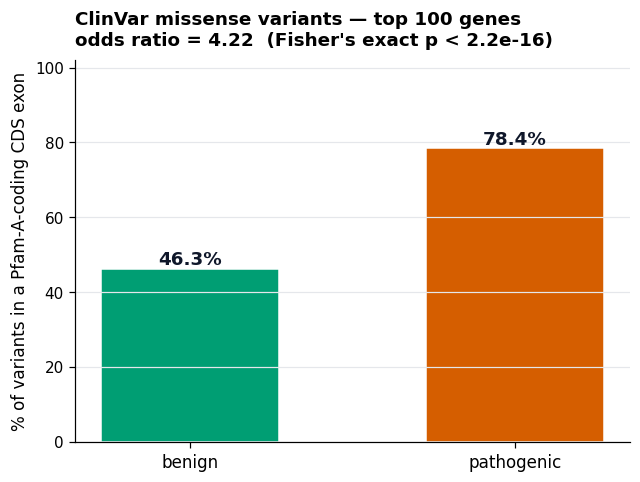

saved /home/goguxor/Desktop/protein2genomic_data/clinvar_enrichment.png


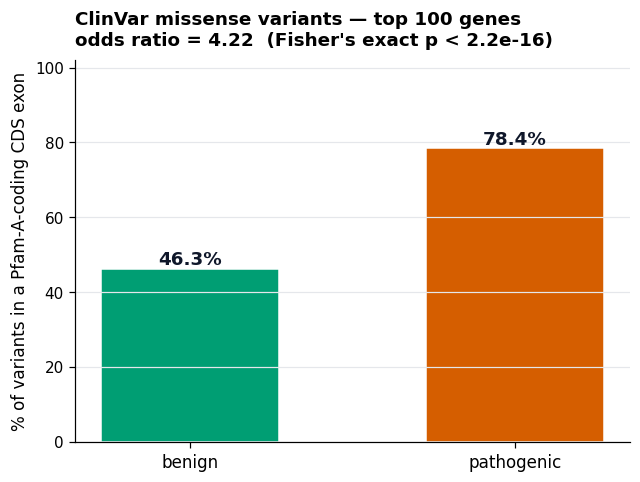

In [7]:
# Force the inline backend — under `jupyter nbconvert --execute` the
# default sometimes lands on Agg, which prints `<Figure …>` instead of
# the actual PNG. The magic call forces module://matplotlib_inline.backend_inline.
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # Not in IPython (e.g. plain python REPL); ignore.
import matplotlib as mpl
import matplotlib.pyplot as plt

# Paper-ready figure defaults. Tweaks vs matplotlib's stock style:
#   - Larger fonts (10pt body, 11pt axis labels, 12pt title).
#   - Thinner spines + only-left/-bottom by default (less chartjunk).
#   - Subtle horizontal grid; no vertical grid.
#   - tab10 palette but used sparingly — we override per-plot.
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'semibold',
    'axes.titlepad': 10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    0.8,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#e5e7eb',
    'grid.linewidth': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'lines.linewidth': 2.0,
})

# Colorblind-safe palette (Wong 2011, also used in seaborn's 'colorblind').
COLORS = {
    'prot2exon':   '#0072B2',  # blue
    'ensembldb':   '#009E73',  # bluish green
    'transvar':    '#E69F00',  # orange
    'rest':        '#CC79A7',  # reddish-purple
    'good':        '#009E73',
    'bad':         '#D55E00',  # vermilion (works for colorblind)
    'neutral':     '#56B4E9',
    'highlight':   '#F0E442',
}

pct = sub.groupby("category")["in_pfam_exon"].mean() * 100
fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(pct.index, pct.values,
              color=[COLORS['good'], COLORS['bad']],
              edgecolor="white", width=0.55)
for b, v in zip(bars, pct.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.2, f"{v:.1f}%",
            ha="center", fontsize=12, fontweight="semibold",
            color="#0f172a")
ax.set_ylabel("% of variants in a Pfam-A-coding CDS exon")
ax.set_xticklabels(pct.index, fontsize=11)
ax.set_title(f"ClinVar missense variants — top {TOP_N} genes\n"
             f"odds ratio = {or_:.2f}  (Fisher's exact p {p_report})",
             loc='left')
ax.set_ylim(0, max(pct.values) * 1.3)
from IPython.display import display
display(fig)
fig.savefig(DATA / "clinvar_enrichment.png", dpi=200, bbox_inches="tight")
print("saved", DATA / "clinvar_enrichment.png")